# Exploratory Data Analysis
**CS/DS 3262 Final Project — TikTok Binge-Session Classifier**

This notebook explores the session-level dataset produced by the preprocessing pipeline.
All plots are saved as PNGs for inclusion in the report.

## 1. Setup & Load Data

In [1]:
import json, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams['figure.dpi'] = 120

DATE_FMT = '%Y-%m-%d %H:%M:%S'
def parse_date(s):
    try: return datetime.strptime((s or '').strip(), DATE_FMT)
    except: return None

with zipfile.ZipFile('TikTok_Data_1776821537.zip') as z:
    with z.open('user_data_tiktok.json') as f:
        data = json.load(f)

act = data['Your Activity']; laf = data['Likes and Favorites']
rows = []
def add(source, primitive, records, date_key='Date'):
    for r in records:
        ts = parse_date(r.get(date_key) or r.get('date', ''))
        if ts: rows.append({'ts': ts, 'source': source, 'primitive': primitive})

add('watch',          'attention',  act.get('Watch History',  {}).get('VideoList', []))
add('search',         'intent',     act.get('Searches',       {}).get('SearchList', []))
add('share',          'social',     act.get('Share History',  {}).get('ShareHistoryList', []))
add('repost',         'social',     act.get('Reposts',        {}).get('RepostList', []))
add('comment',        'social',     data.get('Comment', {}).get('Comments', {}).get('CommentsList', []))
add('like',           'preference', laf.get('Likes', {}).get('ItemFavoriteList', []), date_key='date')
add('favorite_video', 'preference', laf.get('Favorite Videos', {}).get('FavoriteVideoList', []))
add('favorite_sound', 'preference', laf.get('Favorite Sounds', {}).get('FavoriteSoundList', []))

events = pd.DataFrame(rows).sort_values('ts').reset_index(drop=True)
SESSION_GAP = timedelta(minutes=30)
sids = [0]
for i in range(1, len(events)):
    sids.append(sids[-1] + (1 if events.loc[i,'ts'] - events.loc[i-1,'ts'] > SESSION_GAP else 0))
events['session_id'] = sids

def extract_features(grp):
    n = len(grp); duration = (grp['ts'].max() - grp['ts'].min()).total_seconds() / 60.0
    start = grp['ts'].min()
    cascade, last_search = 0, False
    for src in grp.sort_values('ts')['source']:
        if src == 'search': last_search = True
        elif src == 'watch' and last_search: cascade += 1; last_search = False
    return {'session_id': grp['session_id'].iloc[0], 'date': start.date(),
            'event_count': n, 'duration_min': round(duration, 4),
            'peak_epm': round(n / max(duration, 1.0), 4),
            'watch_share': round((grp['primitive']=='attention').mean(), 4),
            'search_share': round((grp['source']=='search').mean(), 4),
            'social_share': round((grp['primitive']=='social').mean(), 4),
            'pref_share': round((grp['primitive']=='preference').mean(), 4),
            'cascade_count': cascade,
            'hour_of_day': start.hour,
            'day_of_week': start.weekday(),
            'has_search': int((grp['source']=='search').any()),
            'has_social': int((grp['primitive']=='social').any())}

raw = pd.DataFrame([extract_features(g) for _, g in events.groupby('session_id')])
daily_counts = events.groupby(events['ts'].dt.date).size()
top10 = daily_counts.quantile(0.90); median_d = daily_counts.median()
binge_days = set(daily_counts[(daily_counts >= top10) & (daily_counts >= 2*median_d)].index)
raw['binge'] = raw['date'].apply(lambda d: int(d in binge_days))
raw['binge_label'] = raw['binge'].map({0: 'Normal', 1: 'Binge'})

print(f'Sessions: {len(raw):,}  |  Binge: {raw["binge"].sum():,} ({raw["binge"].mean():.1%})')
raw[['event_count','duration_min','peak_epm','watch_share','hour_of_day','day_of_week','binge']].head()

Sessions: 7,301  |  Binge: 1,121 (15.4%)


,event_count,duration_min,peak_epm,watch_share,hour_of_day,day_of_week,binge
0,2,12.5833,0.1589,0.0,22,6,0
1,2,2.3667,0.8451,0.0,15,0,0
2,1,0.0000,1.0000,0.0,21,0,0
3,1,0.0000,1.0000,0.0,3,4,0
4,1,0.0000,1.0000,0.0,15,4,0


## 2. Class Distribution

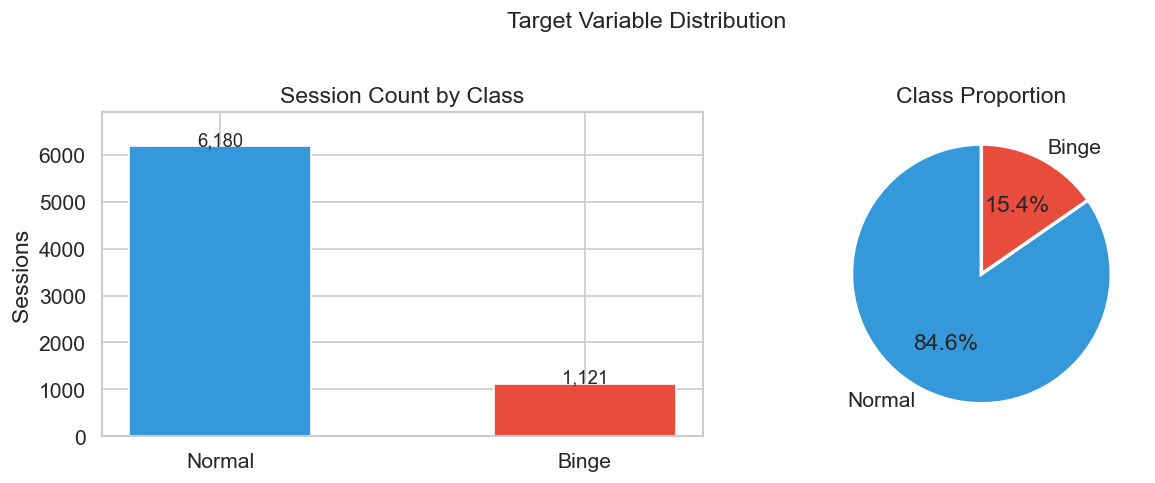

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = raw['binge_label'].value_counts()
bars = axes[0].bar(counts.index, counts.values, color=['#3498db','#e74c3c'], width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 30, f'{val:,}', ha='center', fontsize=11)
axes[0].set_title('Session Count by Class')
axes[0].set_ylabel('Sessions')
axes[0].set_ylim(0, counts.max() * 1.12)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#3498db','#e74c3c'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Class Proportion')

plt.suptitle('Target Variable Distribution', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plot_eda_class_distribution.png', dpi=150)
plt.show()

**Interpretation:** The dataset is moderately imbalanced — 84.6% normal vs. 15.4% binge sessions. This imbalance is realistic (binge days are by definition rare) and justifies using `class_weight='balanced'` in all classifiers and evaluating F1/AUC rather than raw accuracy.

## 3. Histograms of Key Numeric Features

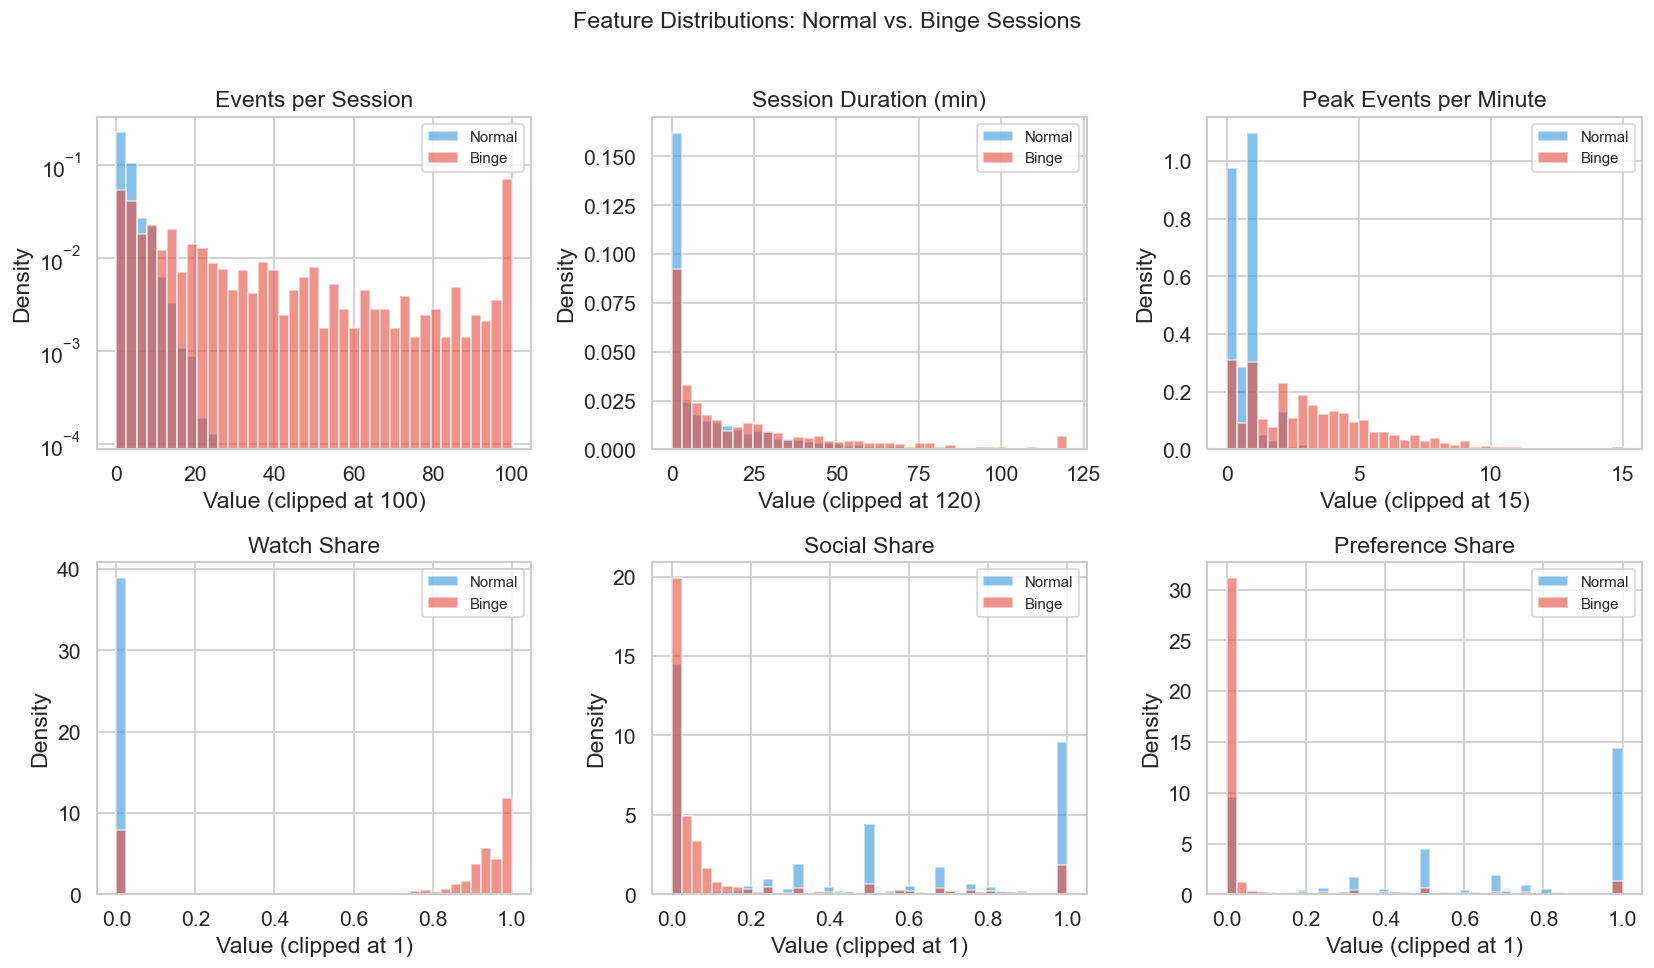

In [3]:
features_info = [
    ('event_count',  'Events per Session',        100, True),
    ('duration_min', 'Session Duration (min)',     120, False),
    ('peak_epm',     'Peak Events per Minute',      15, False),
    ('watch_share',  'Watch Share',                  1, False),
    ('social_share', 'Social Share',                 1, False),
    ('pref_share',   'Preference Share',             1, False),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, (col, label, clip_at, log_y) in zip(axes, features_info):
    bins = np.linspace(0, clip_at, 40)
    for cls, color in [('Normal','#3498db'), ('Binge','#e74c3c')]:
        vals = raw.loc[raw['binge_label']==cls, col].clip(upper=clip_at)
        ax.hist(vals, bins=bins, alpha=0.6, color=color, label=cls, density=True)
    if log_y: ax.set_yscale('log')
    ax.set_title(label)
    ax.set_xlabel(f'Value (clipped at {clip_at})')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Feature Distributions: Normal vs. Binge Sessions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plot_eda_histograms.png', dpi=150)
plt.show()

**Interpretation:** Binge sessions (red) skew heavily right on `event_count` and `duration_min` — they are longer and contain far more events than normal sessions. `watch_share` is more uniformly distributed for binge sessions, suggesting binge days involve proportionally more video watching compared to normal days dominated by likes and favorites.

## 4. Box Plots: Feature Spread by Class

/var/folders/k1/zdbw02jn2snbl3htswrrdnq00000gq/T/ipykernel_65376/2066929259.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='binge_label', y=col,
/var/folders/k1/zdbw02jn2snbl3htswrrdnq00000gq/T/ipykernel_65376/2066929259.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='binge_label', y=col,
/var/folders/k1/zdbw02jn2snbl3htswrrdnq00000gq/T/ipykernel_65376/2066929259.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='binge_label', y=col,
/var/folders/k1/zdbw02jn2snbl3htswrrdnq00000gq

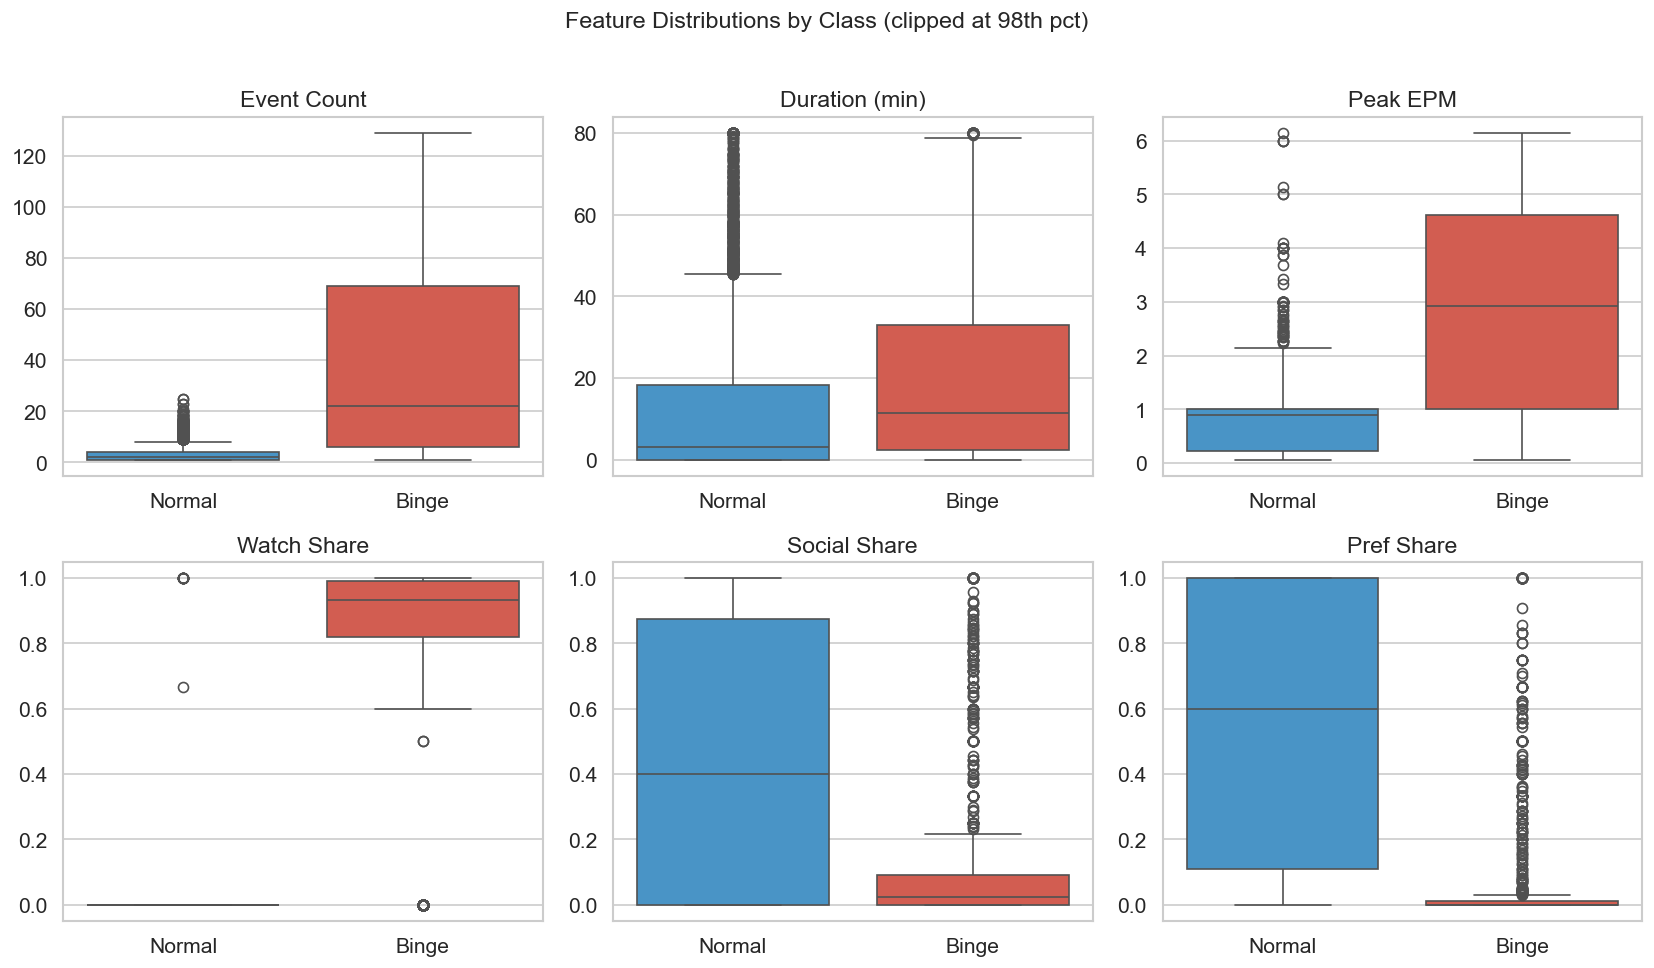

In [4]:
box_features = ['event_count','duration_min','peak_epm','watch_share','social_share','pref_share']
box_labels   = ['Event Count','Duration (min)','Peak EPM','Watch Share','Social Share','Pref Share']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col, label in zip(axes, box_features, box_labels):
    clip_val = raw[col].quantile(0.98)
    plot_df = raw[['binge_label', col]].copy()
    plot_df[col] = plot_df[col].clip(upper=clip_val)
    sns.boxplot(data=plot_df, x='binge_label', y=col,
                palette={'Normal':'#3498db','Binge':'#e74c3c'}, ax=ax)
    ax.set_title(label); ax.set_xlabel(''); ax.set_ylabel('')

plt.suptitle('Feature Distributions by Class (clipped at 98th pct)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plot_eda_boxplots.png', dpi=150)
plt.show()

**Interpretation:** Binge sessions have dramatically higher medians for `event_count`, `duration_min`, and `peak_epm`. `watch_share` is elevated for binge sessions while `social_share` and `pref_share` are lower — binge days are watch-heavy, normal days are interaction-heavy.

## 5. Pairplot — Top 4 Numeric Features

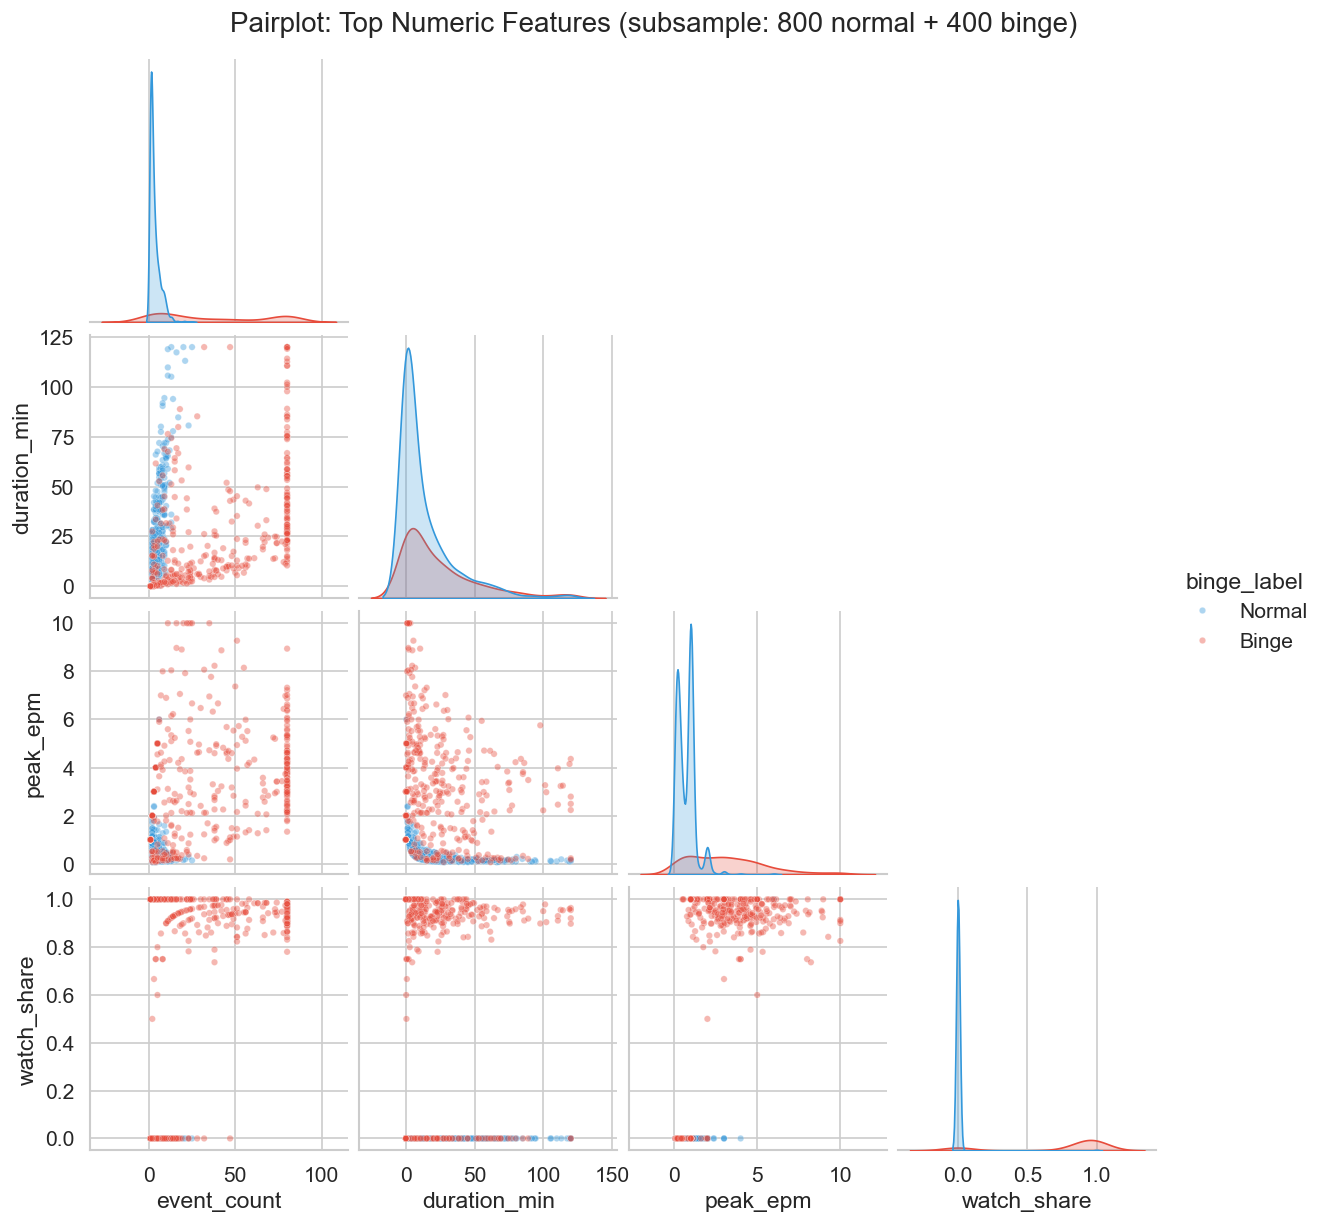

In [5]:
pair_cols = ['event_count','duration_min','peak_epm','watch_share','binge_label']
pair_df = raw[pair_cols].copy()
pair_df['event_count']  = pair_df['event_count'].clip(upper=80)
pair_df['duration_min'] = pair_df['duration_min'].clip(upper=120)
pair_df['peak_epm']     = pair_df['peak_epm'].clip(upper=10)

sample_idx = pd.concat([
    raw[raw['binge']==0].sample(800, random_state=42),
    raw[raw['binge']==1].sample(400, random_state=42)
]).index
pair_sample = pair_df.loc[sample_idx]

g = sns.pairplot(pair_sample, hue='binge_label',
                 palette={'Normal':'#3498db','Binge':'#e74c3c'},
                 plot_kws={'alpha':0.4,'s':15}, diag_kind='kde', corner=True)
g.figure.suptitle('Pairplot: Top Numeric Features (subsample: 800 normal + 400 binge)', y=1.02)
plt.savefig('plot_eda_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The `event_count` vs. `duration_min` panel shows the clearest class separation — binge sessions cluster upper-right while normal sessions cluster near the origin. `peak_epm` adds orthogonal signal: some binge sessions are dense even when short. `watch_share` shows a bimodal pattern, reflecting sessions that are either entirely watch-based or entirely non-watch.

## 6. Cross-Tab: Binge Rate by Hour of Day

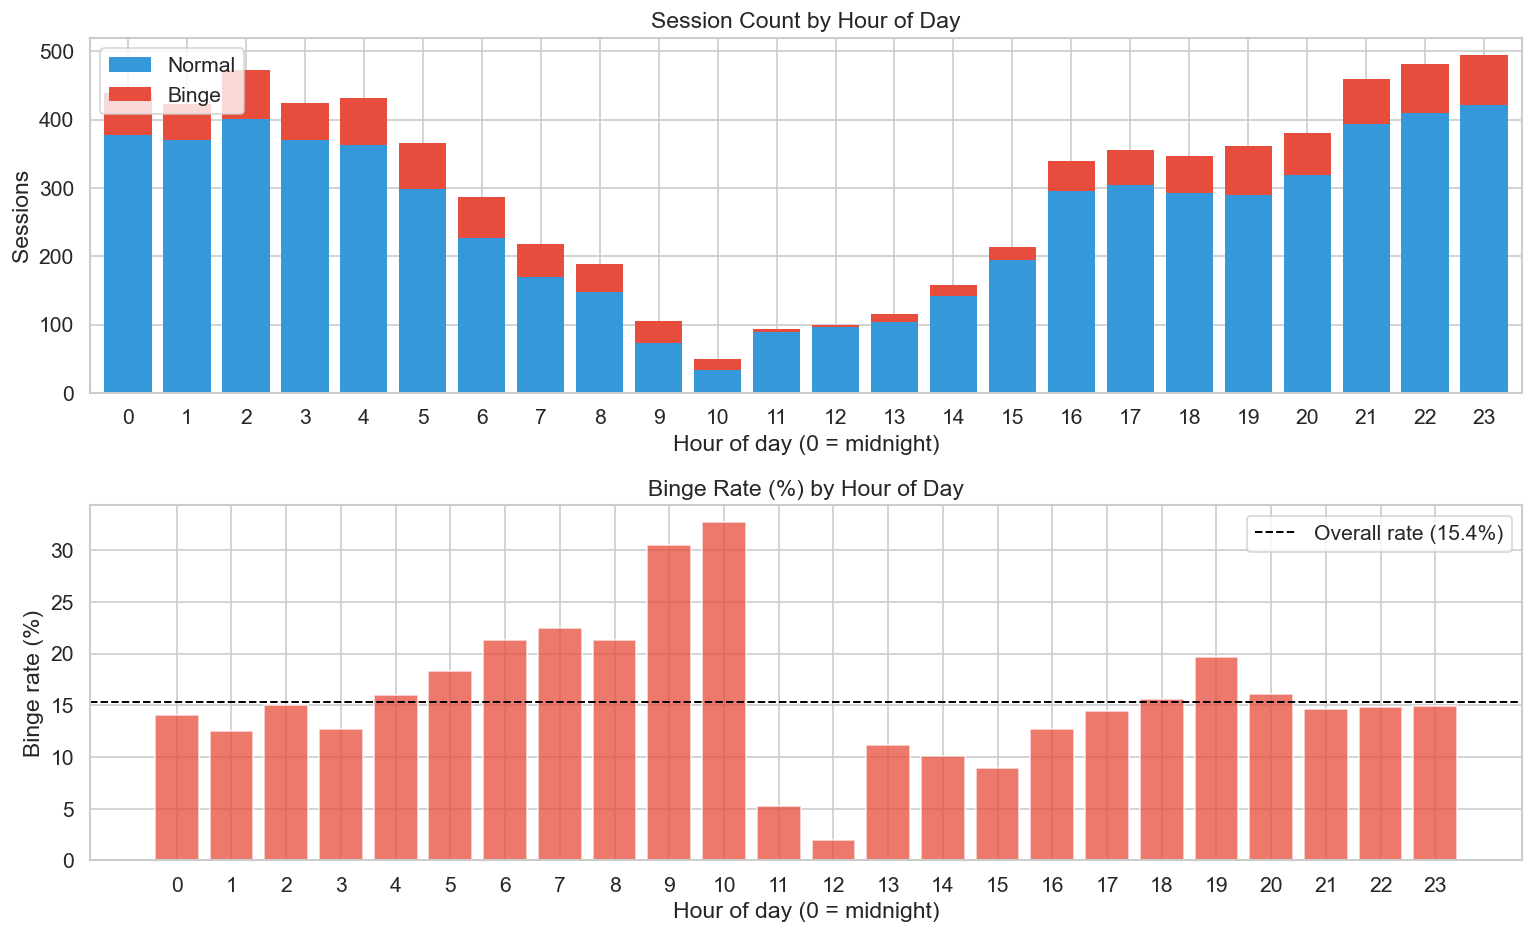

Cross-tab: Binge rate by hour of day


,Sessions,Binge count,Binge rate %
hour_of_day,,,
0,439,62,14.1
1,423,53,12.5
2,472,71,15.0
3,424,54,12.7
4,432,69,16.0
5,366,67,18.3
6,287,61,21.3
7,218,49,22.5
8,188,40,21.3


In [6]:
DAY_NAMES = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

crosstab_hour = pd.crosstab(raw['hour_of_day'], raw['binge_label'])
binge_rate_hour = (crosstab_hour['Binge'] / crosstab_hour.sum(axis=1) * 100).round(1)

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

crosstab_hour[['Normal','Binge']].plot(
    kind='bar', stacked=True, ax=axes[0],
    color=['#3498db','#e74c3c'], width=0.8, edgecolor='none')
axes[0].set_title('Session Count by Hour of Day')
axes[0].set_xlabel('Hour of day (0 = midnight)')
axes[0].set_ylabel('Sessions')
axes[0].legend(loc='upper left')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

axes[1].bar(binge_rate_hour.index, binge_rate_hour.values, color='#e74c3c', alpha=0.75)
axes[1].axhline(raw['binge'].mean()*100, color='black', linestyle='--', linewidth=1.2,
                label=f'Overall rate ({raw["binge"].mean()*100:.1f}%)')
axes[1].set_title('Binge Rate (%) by Hour of Day')
axes[1].set_xlabel('Hour of day (0 = midnight)')
axes[1].set_ylabel('Binge rate (%)')
axes[1].set_xticks(range(24))
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_eda_crosstab_hour.png', dpi=150)
plt.show()

print('Cross-tab: Binge rate by hour of day')
pd.DataFrame({'Sessions': crosstab_hour.sum(axis=1),
              'Binge count': crosstab_hour['Binge'],
              'Binge rate %': binge_rate_hour})

**Interpretation:** Binge rate peaks in late-night hours (0–3 AM) and again in early evening (18–21), both above the 15.4% baseline. Sessions starting mid-morning (9–11 AM) have the lowest binge rates, suggesting habitual casual checking. This temporal pattern justifies including hour-of-day as a feature despite its modest individual correlation with the target.

## 7. Cross-Tab: Binge Rate by Day of Week

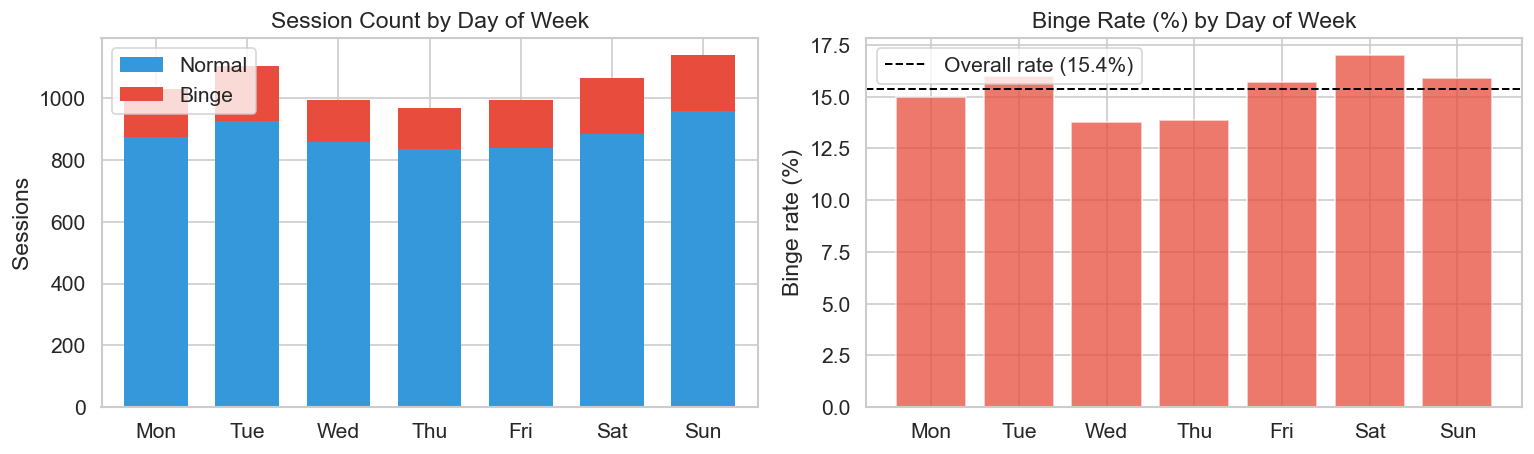

Cross-tab: Binge rate by day of week


,Sessions,Binge count,Binge rate %
Mon,1030,155,15.0
Tue,1103,176,16.0
Wed,996,137,13.8
Thu,970,135,13.9
Fri,996,156,15.7
Sat,1067,181,17.0
Sun,1139,181,15.9


In [7]:
crosstab_dow = pd.crosstab(raw['day_of_week'], raw['binge_label'])
binge_rate_dow = (crosstab_dow['Binge'] / crosstab_dow.sum(axis=1) * 100).round(1)
crosstab_dow.index = DAY_NAMES
binge_rate_dow.index = DAY_NAMES

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

crosstab_dow[['Normal','Binge']].plot(
    kind='bar', stacked=True, ax=axes[0],
    color=['#3498db','#e74c3c'], width=0.7, edgecolor='none')
axes[0].set_title('Session Count by Day of Week')
axes[0].set_ylabel('Sessions')
axes[0].set_xticklabels(DAY_NAMES, rotation=0)
axes[0].legend()

axes[1].bar(DAY_NAMES, binge_rate_dow.values, color='#e74c3c', alpha=0.75)
axes[1].axhline(raw['binge'].mean()*100, color='black', linestyle='--', linewidth=1.2,
                label=f'Overall rate ({raw["binge"].mean()*100:.1f}%)')
axes[1].set_title('Binge Rate (%) by Day of Week')
axes[1].set_ylabel('Binge rate (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_eda_crosstab_dow.png', dpi=150)
plt.show()

print('Cross-tab: Binge rate by day of week')
pd.DataFrame({'Sessions': crosstab_dow.sum(axis=1),
              'Binge count': crosstab_dow['Binge'],
              'Binge rate %': binge_rate_dow})

**Interpretation:** Saturday and Sunday show elevated binge rates, consistent with users having longer unstructured time blocks. Weekdays are at or below the baseline, with Friday slightly elevated — a plausible end-of-week pattern. The magnitude is modest, supporting the cyclical encoding choice over treating day-of-week as a strong standalone predictor.

## 8. Event Composition Over Time

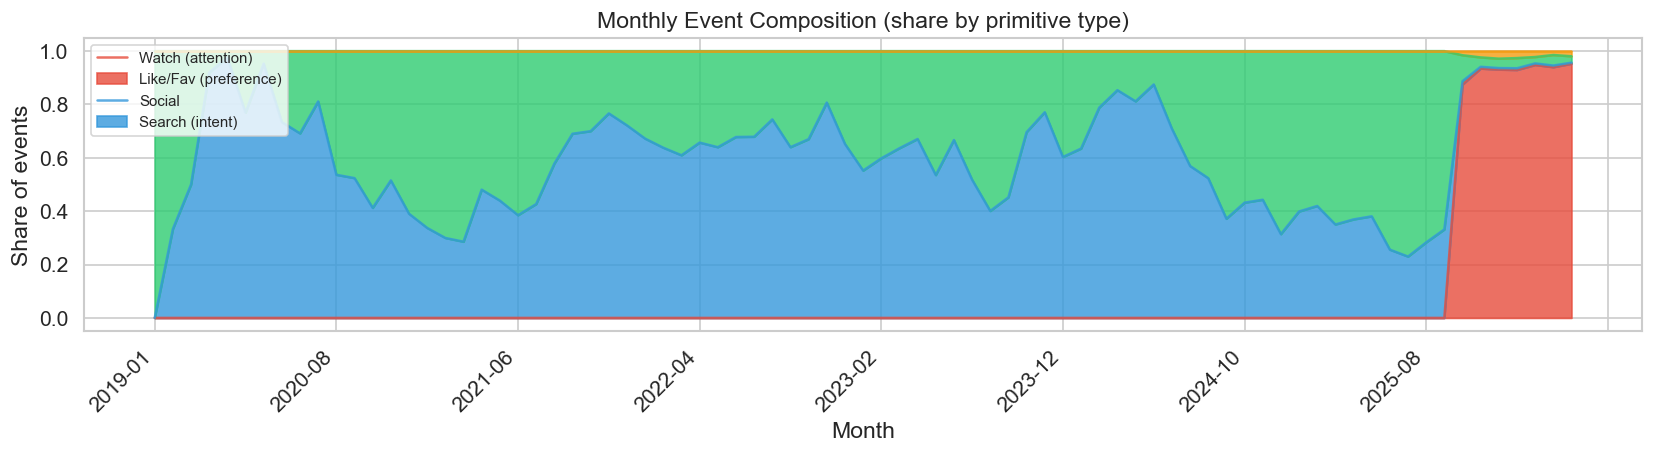

In [8]:
events['month'] = events['ts'].dt.to_period('M').astype(str)
monthly = events.groupby(['month','primitive']).size().unstack(fill_value=0)
monthly = monthly.div(monthly.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 4))
monthly[['attention','preference','social','intent']].plot(
    kind='area', stacked=True, ax=ax, alpha=0.8,
    color=['#e74c3c','#3498db','#2ecc71','#f39c12'])
ax.set_title('Monthly Event Composition (share by primitive type)')
ax.set_xlabel('Month')
ax.set_ylabel('Share of events')
ax.legend(['Watch (attention)','Like/Fav (preference)','Social','Search (intent)'],
          loc='upper left', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_eda_event_composition.png', dpi=150)
plt.show()

**Interpretation:** Watch events dominate throughout the account history, but preference events (likes/favorites) grow substantially from 2024 onward — possibly reflecting a behavioral shift from passive scrolling toward deliberate content saving. This motivates including both `watch_share` and `pref_share` as distinct features rather than collapsing them into a single engagement metric.

## 9. Summary Statistics by Class

In [9]:
summary_cols = ['event_count','duration_min','peak_epm','watch_share',
                'social_share','pref_share','cascade_count']

stats = raw.groupby('binge_label')[summary_cols].agg(['mean','median','std']).round(3)
print('Summary statistics by class:')
stats

Summary statistics by class:


event_count                duration_min                 peak_epm  \
                   mean median     std         mean  median     std     mean   
binge_label                                                                    
Binge            59.112   22.0  98.599       24.118  11.383  33.015    3.263   
Normal            3.112    2.0   2.887       12.407   3.100  19.294    0.738   

                          watch_share  ...        social_share                \
            median    std        mean  ...    std         mean median    std   
binge_label                            ...                                     
Binge        2.918  2.606       0.750  ...  0.383        0.146  0.023  0.276   
Normal       0.897  0.589       0.001  ...  0.037        0.433  0.400  0.404   

            pref_share               cascade_count                
                  mean median    std          mean median    std  
binge_label                                                       
Binge            0.089    0.0  0.229         1.274    0.0  3.055  
Normal           0.565    0.6  0.404         0.000    0.0  0.025  

[2 rows x 21 columns]